In [44]:
import os
import pickle as pickle
import glob
import skimage
import skimage.transform
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import csv
from mpl_toolkits.axes_grid1 import host_subplot

import sys
%matplotlib inline

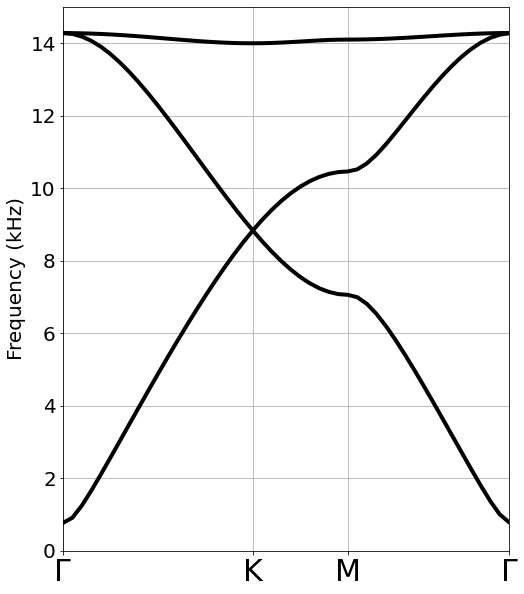

In [3]:
b_sim = []
band1 = []
band2 = []
band3 = []

with open('../../data/simulation/kagome_PLAcover_clean-allbands.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)
    
    for row in reader:
        b_sim.append(float(row[0]))
        band1.append(float(row[1])/1000)
        band2.append(float(row[2])/1000)
        band3.append(float(row[3])/1000)
        




plt.figure(figsize = (8, 10))
#plt.imshow(np.log(reciprocal_data_plot), cmap = 'binary', extent = [b[0], b[-1], freq_min, freq_max], aspect = 'auto', origin = 'lower')
#plt.colorbar()
plt.plot(b_sim, band1, 'k-', linewidth = 4)
plt.plot(b_sim, band2, 'k-', linewidth = 4)
plt.plot(b_sim, band3, 'k-', linewidth = 4)
plt.ylabel("Frequency (kHz)", fontsize = 20)
plt.yticks(np.linspace(0, 14, 8), fontsize=20)
plt.xticks([0, 1, 1.5 , 2.35], ['\u0393', 'K', 'M', '\u0393'], fontsize=30)
plt.axis([0, 2.35, 0, 15])
plt.grid()
plt.savefig("../../data/simulation/kagome_band")

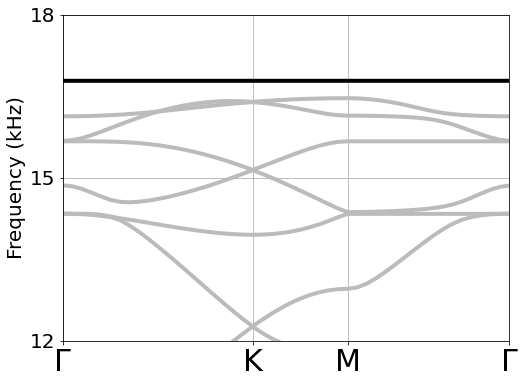

In [10]:
b_sim = []
band = np.zeros((48,14))
with open('../../data/simulation/APS-extkag-bands.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)
    
    i = 0
    for row in reader:
        b_sim.append(float(row[0]))
        
        for j in range(14):
            band[i][j] = float(row[j+1])
            
        i += 1
        


plt.figure(figsize = (8, 6))
#plt.imshow(np.log(reciprocal_data_plot), cmap = 'binary', extent = [b[0], b[-1], freq_min, freq_max], aspect = 'auto', origin = 'lower')
#plt.colorbar()

for i in range(13):
    plt.plot(b_sim, band[:,i], linestyle = '-', color = '#BBBBBB', linewidth = 4)
    
plt.plot(b_sim, band[:,13], 'k-', linewidth = 4)
plt.ylabel("Frequency (kHz)", fontsize = 20)
plt.yticks(np.linspace(0, 18, 7), fontsize=20)
plt.xticks([0, 1, 1.5 , 2.35], ['\u0393', 'K', 'M', '\u0393'], fontsize=30)
plt.axis([0, 2.35, 12, 18])
plt.grid()
plt.savefig("../../data/simulation/extkag_band")

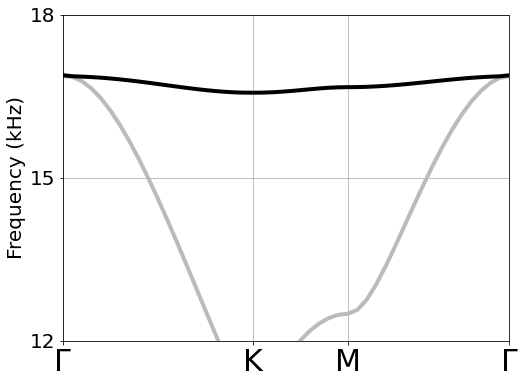

In [9]:
b_sim = []
band = np.zeros((48,14))
with open('../../data/simulation/APS-kagome-bands.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)
    
    i = 0
    for row in reader:
        b_sim.append(float(row[0]))
        
        for j in range(3):
            band[i][j] = float(row[j+1])
            
        i += 1
        


plt.figure(figsize = (8, 6))
#plt.imshow(np.log(reciprocal_data_plot), cmap = 'binary', extent = [b[0], b[-1], freq_min, freq_max], aspect = 'auto', origin = 'lower')
#plt.colorbar()

for i in range(2):
    plt.plot(b_sim, band[:,i], linestyle = '-', color = '#BBBBBB', linewidth = 4)
    
plt.plot(b_sim, band[:,2], 'k-', linewidth = 4)
plt.ylabel("Frequency (kHz)", fontsize = 20)
plt.yticks(np.linspace(0, 18, 7), fontsize=20)
plt.xticks([0, 1, 1.5 , 2.35], ['\u0393', 'K', 'M', '\u0393'], fontsize=30)
plt.axis([0, 2.35, 12, 18])
plt.grid()
plt.savefig("../../data/simulation/kagome_band")

# Plot the tight-binding model calculation and simulated acoustic kagome band structure

In [12]:
b_sim = []
bands_sim = np.zeros((3, 0))  # Initialize an empty array with 3 rows

with open('../../../data/simulation/kagome_machine_bands_clean.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)

    for row in reader:
        b_sim.append(float(row[0]))
        bands_sim = np.hstack((bands_sim, np.array([[float(row[1])], [float(row[2])], [float(row[3])]])))

b_sim = np.array(b_sim)

In [56]:
# calculate the tight-binding results

L=1

k_res = len(b_sim)
# Define the GKMG sweep in reciprocal space
kx1 = np.linspace(0, 2*np.pi/3/L, int(k_res/(3+np.sqrt(3))*2), endpoint=False)
ky1 = np.linspace(0, 0, int(k_res/(3+np.sqrt(3))*2), endpoint=False)

kx2 = np.linspace(2*np.pi/3/L, 3/2*np.pi/3/L, int(k_res/(3+np.sqrt(3))), endpoint=False)
ky2 = np.linspace(0, np.pi/np.sqrt(3)/2/L, int(k_res/(3+np.sqrt(3))), endpoint=False)

kx3 = np.linspace(3/2*np.pi/3/L, 0, int(np.ceil(k_res/(3+np.sqrt(3))*np.sqrt(3))), endpoint=False)
ky3 = np.linspace(np.pi/np.sqrt(3)/2/L, 0, int(np.ceil(k_res/(3+np.sqrt(3))*np.sqrt(3))), endpoint=False)

kx_sweep = np.concatenate([kx1, kx2, kx3])
ky_sweep = np.concatenate([ky1, ky2, ky3])

bands_TB = np.zeros((3, len(kx_sweep)))  # Placeholder for band energies
t = 1

for i, (kx, ky) in tqdm(enumerate(zip(kx_sweep, ky_sweep))):
    M = -t*np.array([[0, 1+np.exp(-1j*2*kx*L), 1+np.exp(-1j*(kx-np.sqrt(3)*ky)*L)],
                     [1+np.exp(1j*2*kx*L), 0, 1+np.exp(1j*(kx+np.sqrt(3)*ky)*L)],
                     [1+np.exp(1j*(kx-np.sqrt(3)*ky)*L), 1+np.exp(-1j*(kx+np.sqrt(3)*ky)*L), 0]])

    bands_TB[:,i] = np.linalg.eigvalsh(M)

48it [00:00, 42771.74it/s]


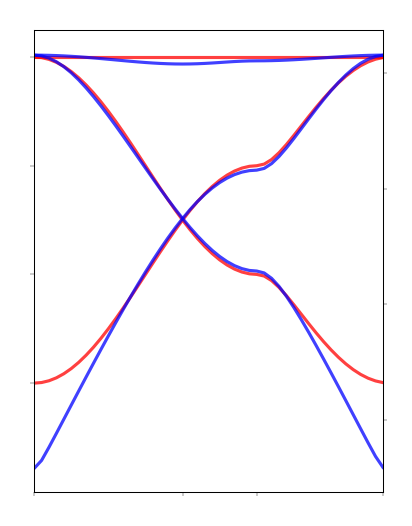

In [111]:
# Set figure size and DPI when creating the figure
fig = plt.figure(figsize=(1.5, 2), dpi=300)
host = host_subplot(111)
par = host.twinx()

host.set_xlim(0, b_sim[-1])
host.set_ylim(-6, 2.5)
par.set_ylim(-0.5, 15.5)

host.set_xticks([0, 1, 1.5 , 2.35], ['', '', '', ''])
host.set_yticks(np.linspace(-4, 2, 4, endpoint=True), ['', '', '', ''])
par.set_yticks(np.linspace(2, 14, 4, endpoint=True), ['', '', '', ''])
host.xaxis.set_tick_params(width=0.1, length = 1)
host.yaxis.set_tick_params(width=0.1, length = 1)
par.yaxis.set_tick_params(width=0.1, length = 1)

for axis in ['top','bottom','left','right']:
    host.spines[axis].set_linewidth(0.25)
    par.spines[axis].set_linewidth(0.25)

for i in range(len(bands_sim)):
    host.plot(b_sim, bands_TB[i], 'r-', linewidth=0.75, alpha=0.75, label = 'Tight-binding' if i == 0 else "")
    par.plot(b_sim, bands_sim[i], 'b-', linewidth=0.75, alpha=0.75, label = 'Acoustic simulation' if i == 0 else "")


plt.savefig("../../../paper_new/intro_fig/kagome_bands_intro.pdf")
plt.show()

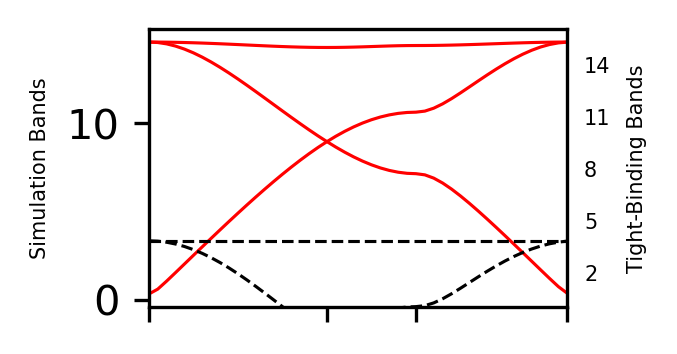

In [43]:
plt.figure(figsize = (1.8, 1.2), dpi = 300)
plt.plot(b_sim, band1, 'r-', linewidth = 0.75)
plt.plot(b_sim, band2, 'r-', linewidth = 0.75)
plt.plot(b_sim, band3, 'r-', linewidth = 0.75)
plt.yticks(np.linspace(2, 14, 5), fontsize=20)
plt.xticks([0, 1, 1.5 , 2.35])
plt.axis([0, 2.35, 0, 16])

ax = plt.gca()

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.25)
    
ax.tick_params(labelbottom=False)
ax.tick_params(labelleft=False)
ax.xaxis.set_tick_params(width=0.1, length = 0.5)
ax.yaxis.set_tick_params(width=0.1, length = 0.5)

plt.savefig("../../../paper_new/intro_fig/kagome_machine_bands.pdf")
plt.show()

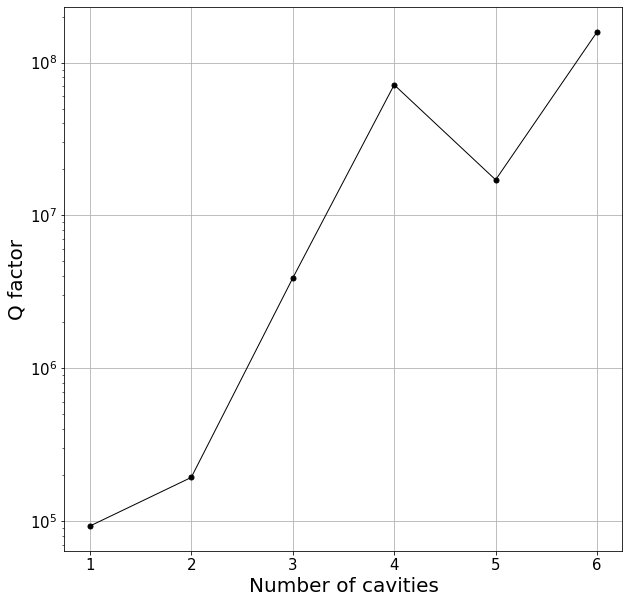

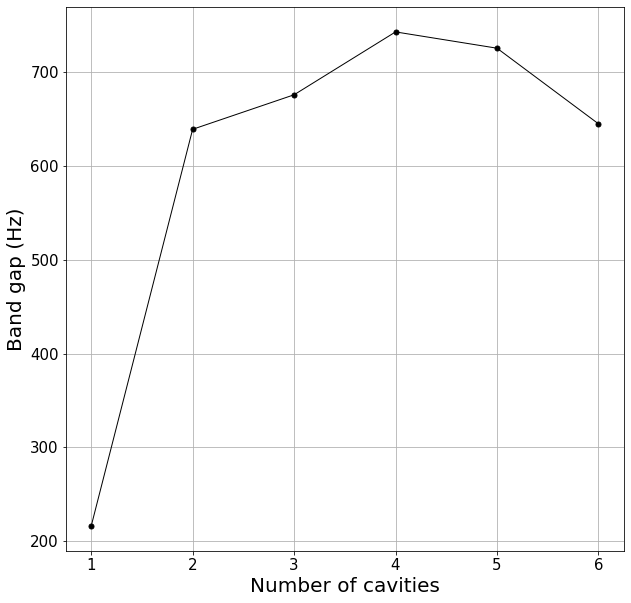

In [32]:
cavity_num = []
q = []
gap = []

with open('../../data/simulation/extkag.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)
    
    for row in reader:
        cavity_num.append(float(row[0]))
        q.append(float(row[1]))
        gap.append(float(row[2]))
        




plt.figure(figsize = (10, 10))
plt.plot(cavity_num, q, 'k-', linewidth = 1)
plt.plot(cavity_num, q, 'k.', markersize = 10)
plt.yscale("log")
plt.ylabel("Q factor", fontsize = 20)
plt.xlabel("Number of cavities", fontsize=20)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
#plt.axis([0, 2.35, 0, 15])
plt.grid()
plt.savefig("../../data/simulation/extkag_Q.png")

plt.figure(figsize = (10, 10))
plt.plot(cavity_num, gap, 'k-', linewidth = 1)
plt.plot(cavity_num, gap, 'k.', markersize = 10)
plt.ylabel("Band gap (Hz)", fontsize = 20)
plt.xlabel("Number of cavities", fontsize=20)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
#plt.axis([0, 2.35, 0, 15])
plt.grid()
plt.savefig("../../data/simulation/extkag_bandgap.png")

